# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Load Data 

In [5]:
df = pd.read_csv("AppReview.csv")
df.head()

,appID,reviewerName,reviewText,reviewerRating,reviewDate,textAnalytics
0,3,Eric Hansen,Love it! WELL worth the money for the full ver...,1.0,2017/07/07 00:00:00,NaN
1,3,Jacob N.,There's an awful bug that doesn't allow you to...,0.4,2017/08/29 00:00:00,NaN
2,3,Higgins Family,Would be 5 stars except for the bugs.... For e...,0.8,2017/10/02 00:00:00,NaN
3,3,Rajko Dikmann,Worked perfect until a few weeks ago. Then bro...,0.4,2017/09/28 00:00:00,NaN
4,3,Sergei Garcia,Hands down the best browser on the play store!...,1.0,2017/07/09 00:00:00,NaN


In [6]:
df.shape

(111143, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111143 entries, 0 to 111142
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   appID           111143 non-null  int64  
 1   reviewerName    105840 non-null  object 
 2   reviewText      111143 non-null  object 
 3   reviewerRating  111143 non-null  float64
 4   reviewDate      111143 non-null  object 
 5   textAnalytics   487 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 5.1+ MB


# 1. Data Quality Check

In [8]:
# check unique values for each variable
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].nunique())


Column: appID
492

Column: reviewerName
79372

Column: reviewText
100936

Column: reviewerRating
6

Column: reviewDate
6104

Column: textAnalytics
48


In [9]:
# check null values for each column 
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].isnull().sum())


Column: appID
0

Column: reviewerName
5303

Column: reviewText
0

Column: reviewerRating
0

Column: reviewDate
0

Column: textAnalytics
110656


In [10]:
# Check duplicate reviews
df.duplicated().sum()

160

# 2. Data Cleaning

In [11]:
# Remove duplicates
df = df.drop_duplicates()

In [12]:
# Drop textAnalytics and reviewerName (too many missing)
df = df.drop(columns=['textAnalytics', 'reviewerName'], errors='ignore')

## 2.1 Text Cleaning

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_review'] = df['reviewText'].apply(clean_text)
df.head()

,appID,reviewText,reviewerRating,reviewDate,clean_review
0,3,Love it! WELL worth the money for the full ver...,1.0,2017/07/07 00:00:00,love it well worth the money for the full vers...
1,3,There's an awful bug that doesn't allow you to...,0.4,2017/08/29 00:00:00,theres an awful bug that doesnt allow you to u...
2,3,Would be 5 stars except for the bugs.... For e...,0.8,2017/10/02 00:00:00,would be stars except for the bugs for exampl...
3,3,Worked perfect until a few weeks ago. Then bro...,0.4,2017/09/28 00:00:00,worked perfect until a few weeks ago then brow...
4,3,Hands down the best browser on the play store!...,1.0,2017/07/09 00:00:00,hands down the best browser on the play store ...


In [14]:
# convert date
df['reviewDate'] = pd.to_datetime(df['reviewDate'], errors='coerce')

df['reviewDate'].head()

0   2017-07-07
1   2017-08-29
2   2017-10-02
3   2017-09-28
4   2017-07-09
Name: reviewDate, dtype: datetime64[ns]

# 3. Feature Engineering

In [15]:
# Review length
df['review_length'] = df['reviewText'].astype(str).apply(len)

df[['reviewText', 'review_length']].head()

,reviewText,review_length
0,Love it! WELL worth the money for the full ver...,365
1,There's an awful bug that doesn't allow you to...,290
2,Would be 5 stars except for the bugs.... For e...,177
3,Worked perfect until a few weeks ago. Then bro...,304
4,Hands down the best browser on the play store!...,234


**A new feature representing review length was introduced to support deeper analysis, particularly in identifying more detailed reviews.**

## 3.1 Sentiment Identification (FR-05)

In [16]:
df['reviewerRating'].unique()

array([1. , 0.4, 0.8, 0.2, 0.6, 0. ])

In [17]:
df["sentiment"] = np.where(
    df["reviewerRating"] <= 0.2, "negative",
    np.where(df["reviewerRating"] <= 0.6, "neutral", "positive")
)

In [18]:
sentiment_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["sentiment_score"] = df["sentiment"].map(sentiment_map)

**In this section, as specified in requirement FR-05, a sentiment column is introduced based on reviewer ratings. The ratings range from 0 to 1 in increments of 0.2 and are used to categorize reviews into three classes: negative (0.2), neutral (≤ 0.6), and positive (> 0.6). Additionally, a numerical encoding (sentiment_score) is created to represent these categories, mapping negative to 0, neutral to 1, and positive to 2, enabling easier use in further analysis and modeling.**

## 3.2 Review Categorization (FR-04)

In [19]:
performance_words = ["slow", "lag", "delay", "load", "speed", "performance"]
usability_words = ["confus", "hard", "difficult", "navig", "design", "ui", "ux"]
failure_words = ["crash", "bug", "error", "freeze", "fail", "issue"]

In [20]:
def categorize_review(text):
    text = str(text).lower()

    # system failure first (highest priority)
    if any(word in text for word in failure_words):
        return "system_failure"
    
    elif any(word in text for word in performance_words):
        return "performance"
    
    elif any(word in text for word in usability_words):
        return "usability"
    
    else:
        return "other"

In [21]:
df["issue_category"] = df["clean_review"].apply(categorize_review)

In [22]:
df[["clean_review", "sentiment", "issue_category"]].head()

,clean_review,sentiment,issue_category
0,love it well worth the money for the full vers...,positive,system_failure
1,theres an awful bug that doesnt allow you to u...,neutral,system_failure
2,would be stars except for the bugs for exampl...,positive,system_failure
3,worked perfect until a few weeks ago then brow...,neutral,performance
4,hands down the best browser on the play store ...,positive,performance


**As specified in requirement FR-04, reviews are categorized into issue types using a keyword-based approach. Three sets of keywords are defined to represent system failure, usability, and performance issues. Each review is analyzed for the presence of these keywords and assigned to the relevant category. Reviews that do not contain any of the defined keywords are labeled as ‘other,’ typically indicating neutral or positive feedback rather than specific issues.**

## 3.3 Priority Score (FR-06)

In [23]:
def priority_score(row):
    sentiment = row["sentiment"]
    issue = row["issue_category"]

    # SYSTEM FAILURE (highest priority group)
    if issue == "system_failure":
        if sentiment == "negative":
            return 1
        elif sentiment == "neutral":
            return 2
        else:  # positive
            return 3

    # PERFORMANCE + USABILITY (medium-low priority)
    elif issue in ["performance", "usability"]:
        return 4

    # EVERYTHING ELSE
    else:
        return 5

In [24]:
df["priority_score"] = df.apply(priority_score, axis=1)

In [25]:
def priority_label(score):
    if score == 1:
        return "P1 - critical (system failure + negative)"
    elif score == 2:
        return "P2 - high (system failure + neutral)"
    elif score == 3:
        return "P3 - medium (system failure + positive)"
    elif score == 4:
        return "P4 - low (performance/usability)"
    else:
        return "P5 - very low (other)"

df["priority_label"] = df["priority_score"].apply(priority_label)

In [26]:
df[["clean_review", "issue_category", "sentiment", "priority_score", "priority_label"]].head()

,clean_review,issue_category,sentiment,priority_score,priority_label
0,love it well worth the money for the full vers...,system_failure,positive,3,P3 - medium (system failure + positive)
1,theres an awful bug that doesnt allow you to u...,system_failure,neutral,2,P2 - high (system failure + neutral)
2,would be stars except for the bugs for exampl...,system_failure,positive,3,P3 - medium (system failure + positive)
3,worked perfect until a few weeks ago then brow...,performance,neutral,4,P4 - low (performance/usability)
4,hands down the best browser on the play store ...,performance,positive,4,P4 - low (performance/usability)


**As specified in requirement FR-06, a priority scoring system is introduced based on a combination of issue category and sentiment. Reviews associated with system failure and negative sentiment are considered highest priority, followed by neutral and positive sentiments within the same category. Reviews categorized under performance and usability are assigned a lower priority level, while all other reviews are treated as the lowest priority. This approach enables structured prioritization of issues based on severity and impact.**

# 4. EDA (Visuals)

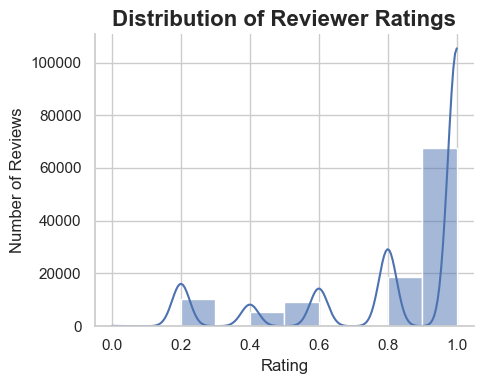

In [28]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(5,4))

ax = sns.histplot(
    df['reviewerRating'],
    bins=10,
    kde=True,                
    color="#4C72B0",         
    edgecolor="white",       
    linewidth=1
)

# Title and labels
ax.set_title("Distribution of Reviewer Ratings", fontsize=16, weight='bold')
ax.set_xlabel("Rating", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)

ax.tick_params(labelsize=11)

sns.despine()

plt.tight_layout()
plt.show()

**This plot shows the distribution of reviewer ratings, with the histogram representing the frequency of ratings and the smooth KDE curve highlighting the overall shape of the data. The distribution is clearly left-skewed toward high values, with a strong concentration of ratings close to 1.0. This suggests that most reviewers gave very positive ratings, while lower ratings (below 0.5) occur relatively infrequently.
In addition, the KDE curve reveals a few minor peaks at intermediate values (around 0.2, 0.5, and 0.8), which may indicate small clusters of users with different satisfaction levels or rating behaviors. However, these are much less prominent compared to the dominant peak near 1.0.**

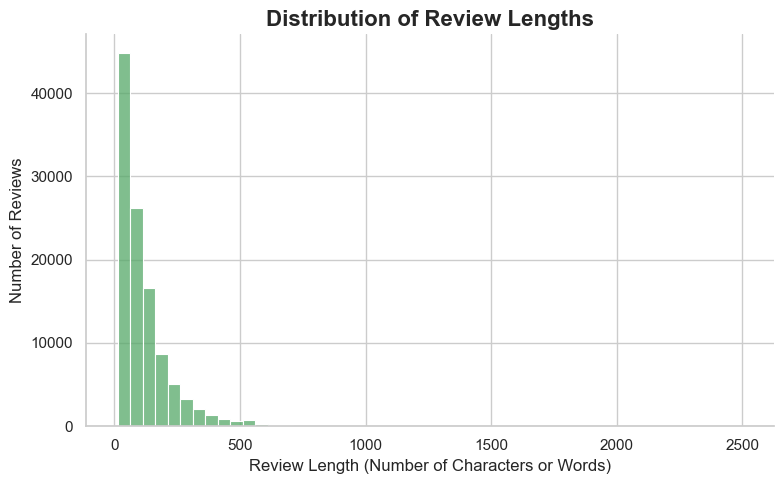

In [29]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

ax = sns.histplot(
    df['review_length'],
    bins=50,
    color="#55A868",
    edgecolor="white",
    linewidth=0.8
)

ax.set_title("Distribution of Review Lengths", fontsize=16, weight='bold')
ax.set_xlabel("Review Length (Number of Characters or Words)", fontsize=12)
ax.set_ylabel("Number of Reviews", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

**The distribution of review lengths is skewed to the right, indicating that most reviewers provided short, less detailed reviews, while a smaller number wrote longer, more extensive feedback.**

C:\Users\fj3504\AppData\Local\Temp\ipykernel_20784\4109886048.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_reviews = df.set_index('reviewDate').resample('M').size()


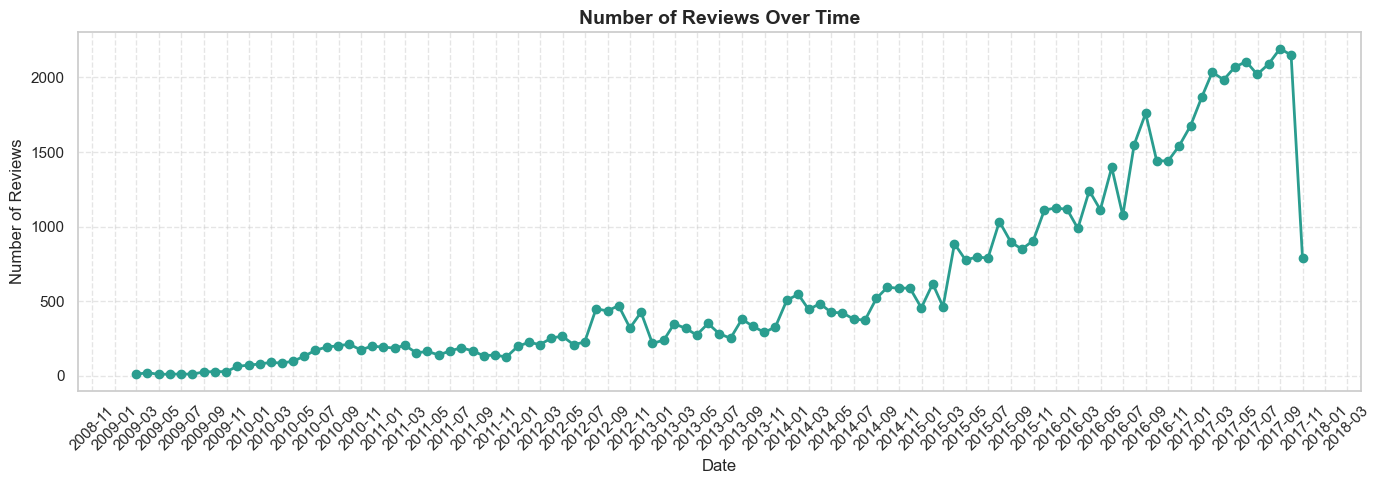

In [30]:
monthly_reviews = df.set_index('reviewDate').resample('M').size()

plt.figure(figsize=(14,5))
plt.plot(monthly_reviews.index, monthly_reviews.values,
         marker='o', linewidth=2, color='#2a9d8f')

plt.title("Number of Reviews Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Overall, the number of reviews shows an upward trend over time despite some fluctuations. However, around September 2017, there is a sharp decline, indicating a possible disruption or change in user activity during that period.**

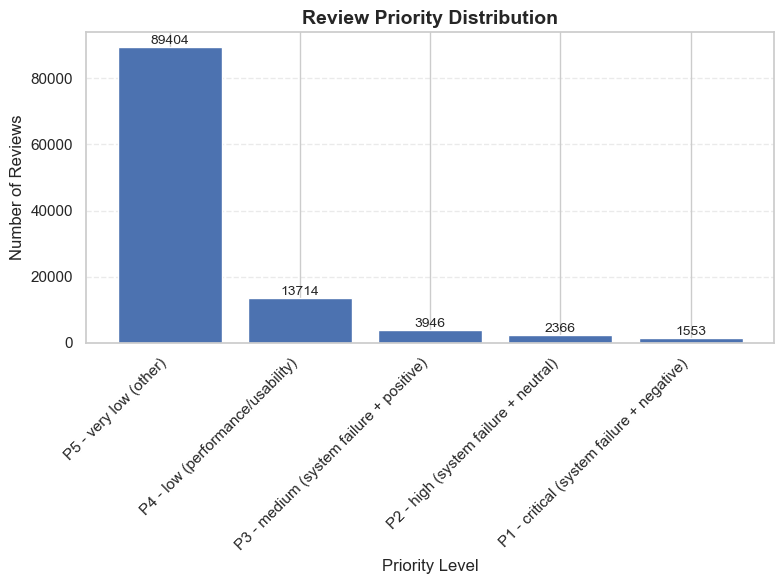

In [195]:
priority_counts = df["priority_label"].value_counts()

plt.figure(figsize=(8,6))
bars = plt.bar(priority_counts.index, priority_counts.values, color="#4c72b0")

plt.title("Review Priority Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Priority Level")
plt.ylabel("Number of Reviews")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**The review priority distribution shows that a large majority of reviews (89,404) fall into the low-priority category. This may be due to the dataset being skewed toward more positive or less critical reviews, resulting in fewer high-priority cases.**

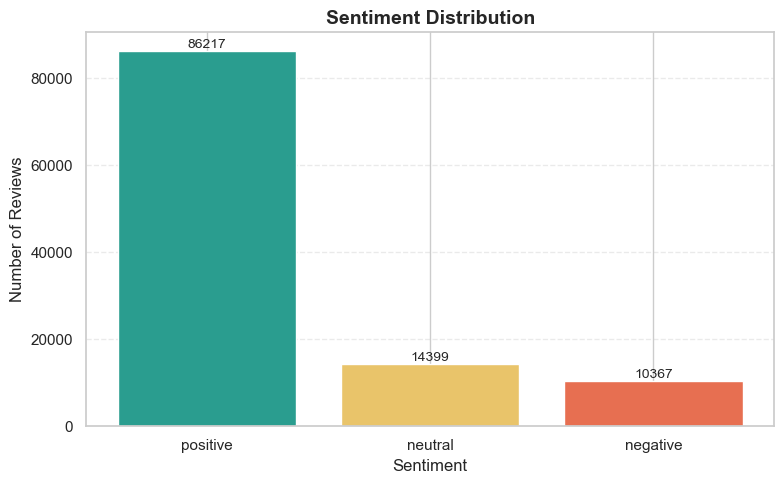

In [196]:
sent_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(sent_counts.index, sent_counts.values, color=["#2a9d8f", "#e9c46a", "#e76f51"])

plt.title("Sentiment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**The sentiment distribution indicates that positive reviews dominate the dataset, with a smaller proportion of neutral (14,399) and negative (10,367) reviews, suggesting an overall favorable bias in user feedback.**

<Figure size 1200x800 with 0 Axes>

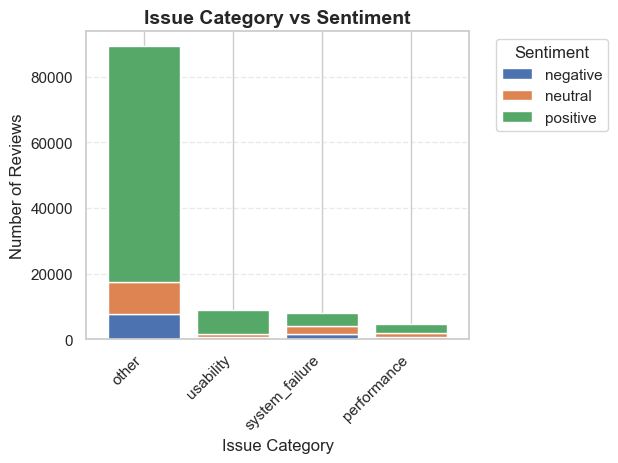

In [198]:
cross = pd.crosstab(df["issue_category"], df["sentiment"])

cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12,8))
cross.plot(kind="bar", stacked=True, width=0.8)

plt.title("Issue Category vs Sentiment", fontsize=14, fontweight='bold')
plt.xlabel("Issue Category")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**This chart shows that the “other” category dominates the dataset by a large margin, with the vast majority of reviews falling into it, and most of those being positive. In contrast, the more specific categories—usability, system failure, and performance—have significantly fewer reviews overall. Across all categories, positive sentiment consistently outweighs neutral and negative feedback, suggesting that users generally have favorable experiences. However, categories like system failure and performance show a relatively higher share of negative and neutral reviews compared to others, indicating these areas may need more attention for improvement.**

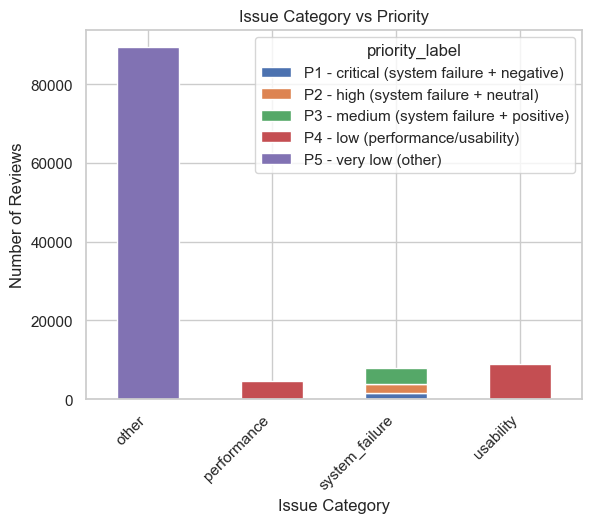

In [31]:
cross2 = pd.crosstab(df["issue_category"], df["priority_label"])
cross2.plot(kind="bar", stacked=True)

plt.title("Issue Category vs Priority")
plt.xlabel("Issue Category")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Reviews")
plt.show()

**This chart highlights that the majority of reviews fall under the “other” category and are classified as very low priority (P5), indicating they are less critical and likely do not require immediate action. In contrast, system failure issues, although fewer in number, are spread across higher priority levels (P1–P3), showing that they are more critical and demand attention. Usability and performance issues are mostly categorized as low priority (P4), suggesting they impact user experience but are not as urgent as system failures. Overall, the graph suggests that while most feedback is low priority, critical issues are concentrated in system-related failures and should be prioritized for resolution.**

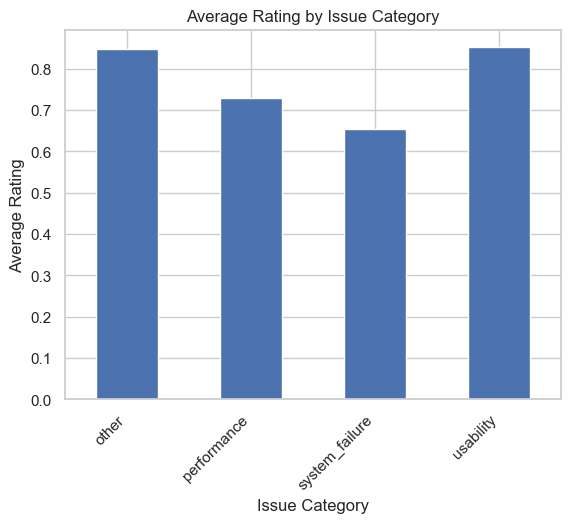

In [32]:
df.groupby("issue_category")["reviewerRating"].mean().plot(kind="bar")
plt.title("Average Rating by Issue Category")
plt.xlabel("Issue Category")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Rating")
plt.show()

**This chart shows that usability and other categories have the highest average ratings, suggesting users are generally satisfied with these aspects. In contrast, performance has a moderately lower rating, while system failure has the lowest average rating among all categories, indicating it is the most problematic area for users. Overall, the pattern suggests that technical issues—especially system failures—have a stronger negative impact on user satisfaction compared to usability or less-defined issues, making them a key area for improvement.**

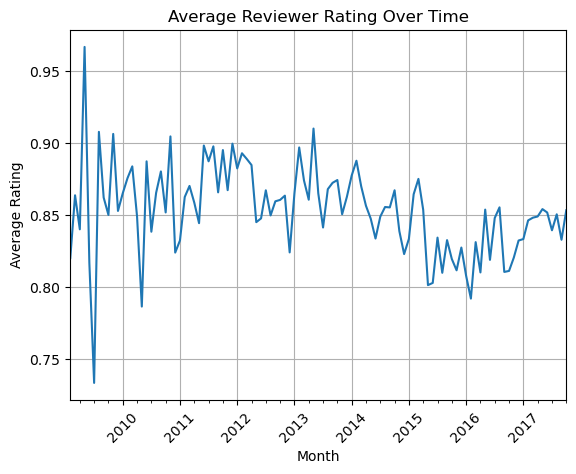

In [151]:
avg_rating_trend = df.groupby(df["reviewDate"].dt.to_period("M"))["reviewerRating"].mean()

avg_rating_trend.plot()

plt.title("Average Reviewer Rating Over Time")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.grid()
plt.show()

**The average reviewer rating from 2009 to 2017 reveals a clear pattern of early instability gradually settling into a more consistent, though slightly declining, trend over time. The period around late 2009 shows the highest recorded ratings, reaching nearly 0.97, suggesting that early reviewers were particularly satisfied during the platform's initial phase. However, this was short-lived, as ratings dropped sharply before stabilizing throughout 2010 to 2014 in a range broadly around 0.85 to 0.90, indicating a generally satisfactory but more tempered level of approval. The most notable decline occurs around 2015 to 2016, where average ratings fall to their lowest sustained levels — dipping close to 0.79 — suggesting that this period represented the most problematic phase for reviewer satisfaction. By 2017, ratings show a modest recovery toward 0.85, though they never return to earlier highs.**